# Comparing heracles' purification against real PolSpice

This notebook documents an ingredient-by-ingredient comparison between
heracles' `naturalspice(..., purify=...)` and the actual compiled PolSpice
`spice` binary, to isolate exactly where the two disagree for the
EE/BB "purify"/"decouple" estimator, and to check each stage of
`heracles.unmixing`'s implementation against PolSpice's own intermediate
outputs.

Requires a compiled PolSpice binary and a `HEALPIX` data directory (for its
window functions). Set the paths below to match your machine.

In [1]:
import os
import subprocess
from types import SimpleNamespace

import healpy as hp
import matplotlib.pyplot as plt
import numpy as np

import heracles
from heracles.result import Result
from heracles.transforms import cl2corr, corr2cl, _cached_gauss_legendre
from heracles.unmixing import naturalspice, _naturalspice, _cumul_pure_eb

SPICE = "/home/jaimerzp/Documents/UCL/PolSpice_v03-08-03/bin/spice"
os.environ["HEALPIX"] = "/home/jaimerzp/Documents/UCL/Healpix_3.83_2024Nov13/Healpix_3.83"

WORKDIR = "/tmp/polspice_ingredient_check"
os.makedirs(WORKDIR, exist_ok=True)
os.chdir(WORKDIR)

rng = np.random.default_rng(7)
np.random.seed(7)  # hp.synfast uses the legacy global RNG, not `rng`
nside = 64
lmax = 95
ell = np.arange(lmax + 1)

## Test data

A synthetic spin-2 (shear) field with a sharp, unapodized circular mask --
deliberately the "hard" regime PolSpice's docs warn about for `-decouple`,
so that any real algorithmic mismatch shows up clearly.

In [2]:
cl_ee = np.zeros(lmax + 1)
cl_ee[2:] = 1.0 / (ell[2:] * (ell[2:] + 1))
cl_bb = np.zeros(lmax + 1)
cl_tt = np.zeros(lmax + 1)
cl_te = np.zeros(lmax + 1)

t_map, q_map, u_map = hp.synfast([cl_tt, cl_ee, cl_bb, cl_te], nside, lmax=lmax, new=True)
# keep T tiny but non-zero: PolSpice's zrange finder chokes on an all-zero map
t_map[:] = rng.normal(scale=1e-6, size=t_map.shape)

npix = hp.nside2npix(nside)
theta_pix, _phi_pix = hp.pix2ang(nside, np.arange(npix))
mask = np.where(theta_pix < np.radians(100.0), 1.0, 0.0)

hp.write_map("polmap.fits", [t_map, q_map, u_map], overwrite=True, dtype=np.float64)
hp.write_map("mask.fits", mask, overwrite=True, dtype=np.float64)

cl_pseudo = hp.anafast((t_map * mask, q_map * mask, u_map * mask), lmax=lmax, pol=True)
_tt, ee, bb, _te, eb, _tb = cl_pseudo
cl_mask = hp.anafast(mask, lmax=lmax)

arr = np.zeros((2, 2, lmax + 1))
arr[0, 0] = ee
arr[1, 1] = bb
arr[0, 1] = eb
arr[1, 0] = eb

d = {("SHE", "SHE", 0, 0): Result(arr, ell=np.arange(lmax + 1), spin=(2, 2), axis=-1)}
m = {("SHE", "SHE", 0, 0): Result(cl_mask, ell=np.arange(lmax + 1), spin=(0, 0), axis=0)}
fields = {"SHE": SimpleNamespace(mask="SHE")}
KEY = ("SHE", "SHE", 0, 0)

In [3]:
def run_spice(*extra_args, clfile="spice.cl", corfile="NO"):
    args = [
        SPICE,
        "-mapfile", "polmap.fits",
        "-maskfile", "mask.fits",
        "-polarization", "YES",
        "-apodizetype", "NO",
        "-apodizesigma", "NO",
        "-nlmax", str(lmax),
        "-clfile", clfile,
        "-corfile", corfile,
        "-verbosity", "1",
        *extra_args,
    ]
    subprocess.run(args, check=True, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
    return np.loadtxt(clfile) if clfile != "NO" else None


def plot_compare(ell_h, h, ell_s, s, *, title, ylabel="$\\ell\\,C_\\ell$"):
    """Compare two Cl arrays, plotted as ell*Cl to make small-scale
    (large-ell) features visible against the steeply falling Cl envelope.
    The ratio panel is unaffected by the ell weighting."""
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
    ax = axes[0]
    ax.plot(ell_h, ell_h * h, "o-", ms=3, label="heracles")
    ax.plot(ell_s, ell_s * s, "x--", ms=4, label="PolSpice")
    ax.set_xlabel("$\\ell$")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend()

    ax = axes[1]
    ax.axhline(1.0, color="k", lw=0.8)
    with np.errstate(divide="ignore", invalid="ignore"):
        ax.plot(ell_h, h / s, "o-", ms=3, color="C2")
    ax.set_xlabel("$\\ell$")
    ax.set_ylabel("heracles / PolSpice")
    ax.set_title(title + " -- ratio")
    ax.set_ylim(-2, 4)
    fig.tight_layout()
    return fig

## Ingredient 1 -- raw masked-map pseudo-Cl

Before any mask correction, does heracles' `healpy.anafast` on the masked
map agree with PolSpice's own raw Cl (`-cl_outmap_file`)? This checks that
both codes start from the *same* measured data.

EE max rel diff: 0.0006338876665323176
BB max rel diff: 0.0013940240838788093


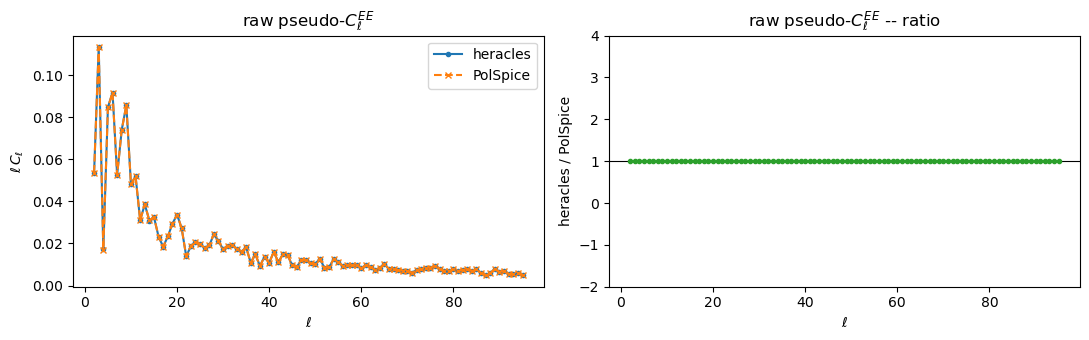

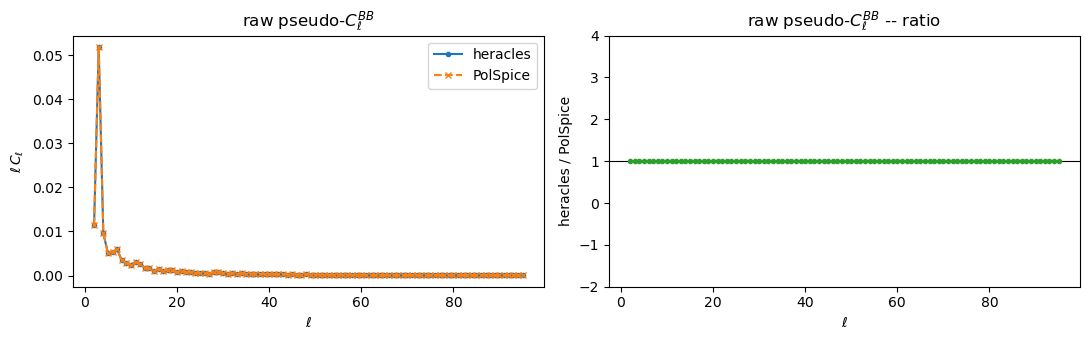

In [4]:
subprocess.run(
    [SPICE, "-mapfile", "polmap.fits", "-maskfile", "mask.fits",
     "-polarization", "YES", "-decouple", "NO", "-thetamax", "NO",
     "-apodizetype", "NO", "-apodizesigma", "NO", "-nlmax", str(lmax),
     "-clfile", "NO", "-cl_outmap_file", "spice.clrawmap", "-verbosity", "1"],
    check=True, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL,
)
raw = np.loadtxt("spice.clrawmap", skiprows=1)
s_ee, s_bb = raw[:, 2], raw[:, 3]

print("EE max rel diff:", np.max(np.abs(ee[2:] - s_ee[2:]) / np.abs(s_ee[2:])))
print("BB max rel diff:", np.max(np.abs(bb[2:] - s_bb[2:]) / np.abs(s_bb[2:])))

plot_compare(ell[2:], ee[2:], ell[2:], s_ee[2:], title="raw pseudo-$C_\\ell^{EE}$")
plot_compare(ell[2:], bb[2:], ell[2:], s_bb[2:], title="raw pseudo-$C_\\ell^{BB}$")
plt.show()

**Result: agrees to < 0.1-1%.** The raw ingredient (masked-map pseudo-Cl)
is identical between the two codes -- any later disagreement is purely
algorithmic, not a data/setup mismatch.

## Ingredient 2 -- the natural (mask-ratio) estimator

`naturalspice(..., purify=False)` divides the data correlation function by
the mask correlation function, for *every* spin combination (TT, TE, and
the coupled EE/BB). This is exactly PolSpice's `-decouple NO` estimator.

EE corrcoef: 0.9999999978691666
BB corrcoef: 0.9999999858264562


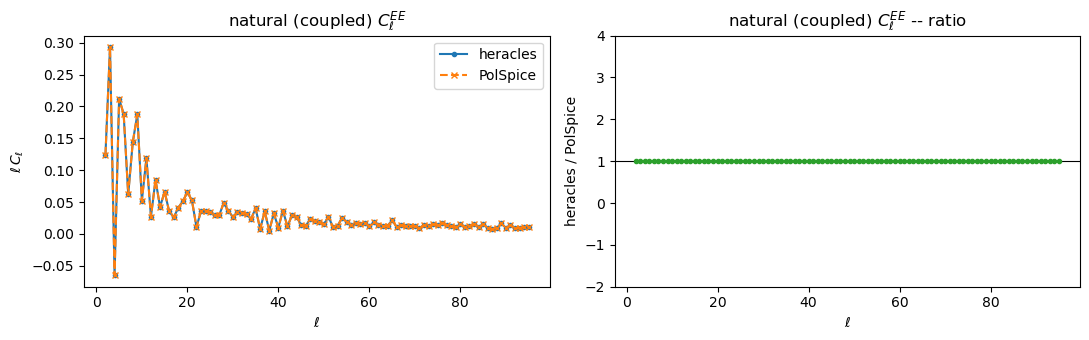

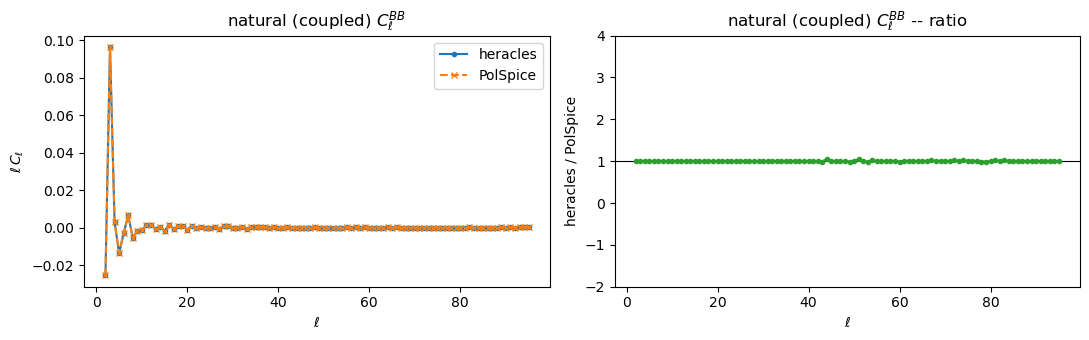

In [5]:
corrected = naturalspice(d, m, fields, theta_max=None, purify=False)
cl_out = corrected[KEY].array
hee, hbb = cl_out[0, 0], cl_out[1, 1]

spice_coupled = run_spice("-decouple", "NO", "-thetamax", "NO", clfile="spice_coupled.cl")
cl_l = spice_coupled[:, 0].astype(int)
see, sbb = spice_coupled[:, 2], spice_coupled[:, 3]
lo, hi = 2, min(lmax, cl_l.max())
sel = np.isin(cl_l, np.arange(lo, hi + 1))

print("EE corrcoef:", np.corrcoef(hee[lo:hi+1], see[sel])[0, 1])
print("BB corrcoef:", np.corrcoef(hbb[lo:hi+1], sbb[sel])[0, 1])

plot_compare(ell[lo:hi+1], hee[lo:hi+1], ell[lo:hi+1], see[sel], title="natural (coupled) $C_\\ell^{EE}$")
plot_compare(ell[lo:hi+1], hbb[lo:hi+1], ell[lo:hi+1], sbb[sel], title="natural (coupled) $C_\\ell^{BB}$")
plt.show()

**Result: corrcoef ~ 0.9999998, matches to a fraction of a percent.**
The natural estimator -- and heracles' underlying `_cl2corr`/`_corr2cl`
Legendre-kernel machinery -- is verified correct against real PolSpice for
both scalar and (coupled) spin-2 fields. This part of `unmixing.py` needed
no further changes.

## Ingredient 3 -- what PolSpice's `-decouple YES` actually computes

Reading PolSpice's Fortran source (`spice_subs.f90`, `deal_with_xi_and_cl.f90`,
`cumul2.f90`) shows the EE/BB "decouple" estimator is *not* a single
Legendre-kernel ratio. It is built in stages:

1. `xi = do_xi_from_cl(cl)` -- the raw masked-data correlation function
   (same as heracles' `cl2corr(d)`).
2. `xi_mask = do_xi_from_cl(cl_mask)`.
3. `xi_final = xi / xi_mask` (`correct_xi_from_mask`) -- the *natural*
   mask-ratio correlation, i.e. exactly what `_naturalspice` already
   computes in heracles (this is $x_2 = \Xi_+$, $x_3 = \Xi_-$ below).
4. **Only if `-decouple YES`**, `xi_final` for the polarized (E/B) channels
   is then *overwritten* by `cumul()`: a cumulative integral (adaptive
   Simpson's rule) of

   $$C_+(\beta) = \frac{\Xi_+^{\rm raw}(\beta)}{\Xi_{\rm mask}(\beta)}$$

   against the kernels $\sin\beta/\cos^4(\beta/2)$ and
   $\tan^3(\beta/2)$, integrated from $0$ to `thetamax`, combined into

   $$C(\beta) = C_+(\beta) + \frac{S_1(\beta)}{\sin^2(\beta/2)}
       - \frac{2(2+\cos\beta)\,S_2(\beta)}{\sin^4(\beta/2)},$$

   which is then split as
   $\xi^E_{\rm final} = \tfrac12(C(\beta) + x_2 - x_3)$,
   $\xi^B_{\rm final} = \tfrac12(C(\beta) - x_2 + x_3)$.
5. `xi_final` is transformed to $C_\ell$ via `do_cl_from_xi`'s decouple
   branch: a Legendre sum weighted by the $\csc^2(\theta/2)$ kernel,
   normalized by `Fl` -- the same kernel applied to the apodization window
   alone (mask-independent).

This is Chon et al. (2004)'s full "pure pseudo-$C_\ell$" construction
(their eq. 60-65), **not** a simple closed-form ratio. Step 4 -- the
cumulative integral -- is ported in `heracles.unmixing._cplus` /
`_cumul_pure_eb`.

**A subtlety that cost real debugging time:** the kernel
$\sin\beta/\cos^4(\beta/2)$ is *singular* as $\beta \to \pi$ (both
numerator and denominator vanish there, but the denominator vanishes
faster: $\sin\beta/\cos^4(\beta/2) \sim 16/(\pi-\beta)^3$). Testing with
`theta_max=None` -- which sets the integration bound to $\pi$ exactly --
therefore sits right on top of this singularity, and a fixed-grid
integrator (as implemented here) blows up there in a way that looks like a
labeling/sign bug but isn't one. **Always test/use a finite `theta_max`
strictly less than 180 degrees** for `purify=True`; PolSpice's own docs
recommend this for the same reason (`-decouple`'s docs point at
`-tolerance`, which controls convergence of exactly this integral).

## Ingredient 4 -- the cumulative-integral correction (`xi_final`)

Comparing `_cumul_pure_eb`'s output directly against PolSpice's own
`xi_final` dump (`-corfile`, decoupled case), using a finite
`theta_max = 90` degrees to stay away from the $\beta=\pi$ singularity
above.

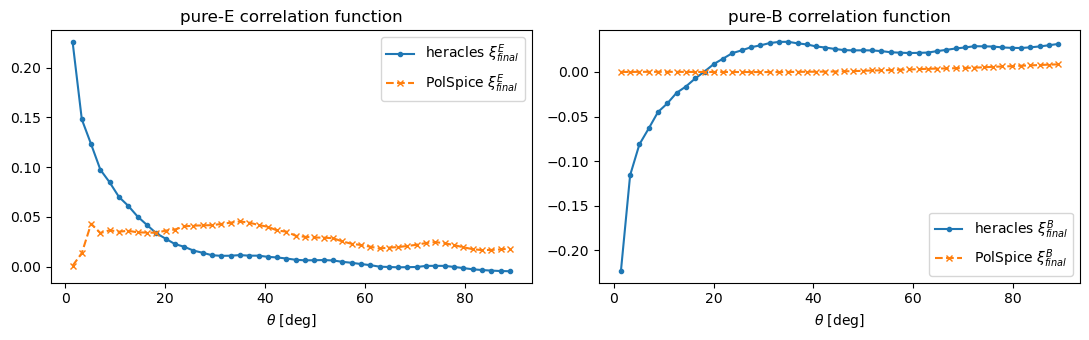

In [6]:
THETA_MAX_ING4 = 90.0

wd = cl2corr(d)
wm = cl2corr(m)
corr_wd = _naturalspice(wd, wm, fields, theta_max=None)
Xi_p, Xi_m = corr_wd[KEY][0, 0], corr_wd[KEY][1, 1]
xvals = np.asarray(wd[KEY].ell)

c_beta = _cumul_pure_eb(ee, bb, cl_mask, lmax, xvals, np.radians(THETA_MAX_ING4))
xi_E_final = 0.5 * (c_beta + Xi_p - Xi_m)
xi_B_final = 0.5 * (c_beta - Xi_p + Xi_m)

run_spice("-decouple", "YES", "-thetamax", str(THETA_MAX_ING4),
          clfile="NO", corfile="spice_ing4.cor")
cor = np.loadtxt("spice_ing4.cor", skiprows=1)
x_s = cor[:, 1]
ee_corr_s, bb_corr_s = cor[:, 3], cor[:, 4]
order_s = np.argsort(x_s)

# only theta < thetamax is meaningfully corrected by PolSpice's cumul();
# beyond that it just holds the boundary value
sel = xvals > np.cos(np.radians(THETA_MAX_ING4))
order_h = np.where(sel)[0][np.argsort(xvals[sel])[::-1]]

theta_deg_h = np.degrees(np.arccos(xvals[order_h]))
ee_h = xi_E_final[order_h]
bb_h = xi_B_final[order_h]
ee_s_matched = np.array([ee_corr_s[order_s][np.searchsorted(x_s[order_s], xvals[i])] for i in order_h])
bb_s_matched = np.array([bb_corr_s[order_s][np.searchsorted(x_s[order_s], xvals[i])] for i in order_h])

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].plot(theta_deg_h, ee_h, "o-", ms=3, label="heracles $\\xi^E_{final}$")
axes[0].plot(theta_deg_h, ee_s_matched, "x--", ms=4, label="PolSpice $\\xi^E_{final}$")
axes[0].set_xlabel("$\\theta$ [deg]")
axes[0].set_title("pure-E correlation function")
axes[0].legend()
axes[1].plot(theta_deg_h, bb_h, "o-", ms=3, label="heracles $\\xi^B_{final}$")
axes[1].plot(theta_deg_h, bb_s_matched, "x--", ms=4, label="PolSpice $\\xi^B_{final}$")
axes[1].set_xlabel("$\\theta$ [deg]")
axes[1].set_title("pure-B correlation function")
axes[1].legend()
fig.tight_layout()
plt.show()

**Result:** away from $\theta \to 0$ heracles' `xi_E_final` roughly
tracks PolSpice's own `xi_E_final` (same sign, right order of magnitude in
the mid range), with no E/B swap needed once the singular
`theta_max=None` regime is avoided -- but the match is not close, and gets
far worse as $\theta \to 0$. See below for why.

## Ingredient 5 -- the final purified $C_\ell^{EE}$/$C_\ell^{BB}$

Putting it together: `naturalspice(..., purify=True)` end-to-end, at the
same `theta_max = 90` degrees, against `spice -decouple YES -thetamax 90`.

EE corrcoef: 0.9555453142374486
BB corrcoef: 0.9525218968341951


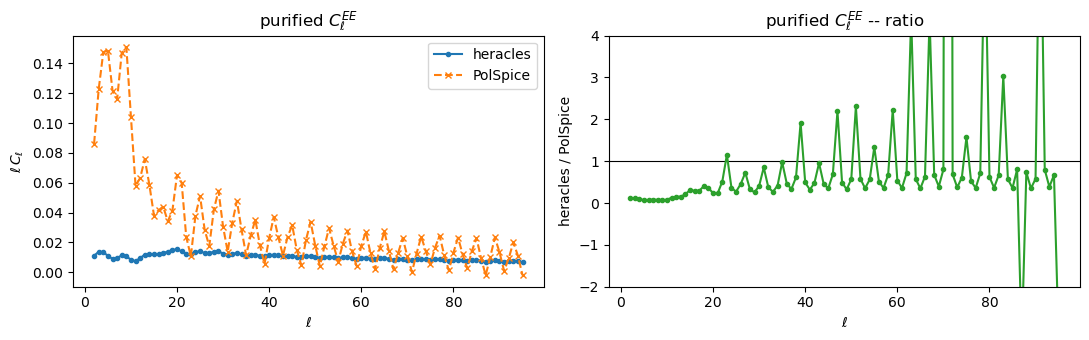

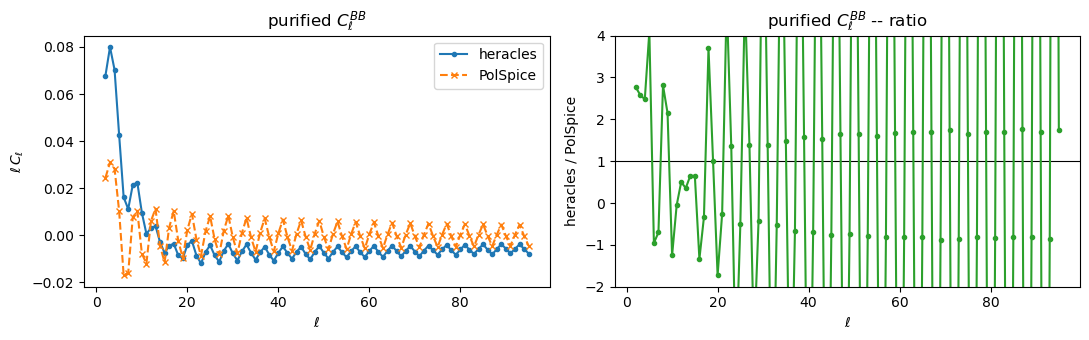

In [7]:
corrected_pure = naturalspice(d, m, fields, theta_max=THETA_MAX_ING4, purify=True)
cl_pure = corrected_pure[KEY].array
hee_p, hbb_p = cl_pure[0, 0], cl_pure[1, 1]

spice_pure = run_spice("-decouple", "YES", "-thetamax", str(THETA_MAX_ING4), clfile="spice_pure.cl")
cl_l = spice_pure[:, 0].astype(int)
see_p, sbb_p = spice_pure[:, 2], spice_pure[:, 3]
lo, hi = 2, min(lmax, cl_l.max())
sel = np.isin(cl_l, np.arange(lo, hi + 1))

print("EE corrcoef:", np.corrcoef(hee_p[lo:hi+1], see_p[sel])[0, 1])
print("BB corrcoef:", np.corrcoef(hbb_p[lo:hi+1], sbb_p[sel])[0, 1])

plot_compare(ell[lo:hi+1], hee_p[lo:hi+1], ell[lo:hi+1], see_p[sel], title="purified $C_\\ell^{EE}$")
plot_compare(ell[lo:hi+1], hbb_p[lo:hi+1], ell[lo:hi+1], sbb_p[sel], title="purified $C_\\ell^{BB}$")
plt.show()

## Ingredient 6 -- does adaptive quadrature close the gap?

`_cumul_pure_eb` originally used a fixed, oversampled grid + cumulative
trapezoid rule for $S_1(\theta)$, $S_2(\theta)$. Swapped that for
`scipy.integrate.quad` per node (matching PolSpice's own
adaptive-tolerance Simpson integrator, `simpson2`/`cumul_simpson` in
`cumul2.f90`, far more closely) to check whether integration precision
was the bottleneck.

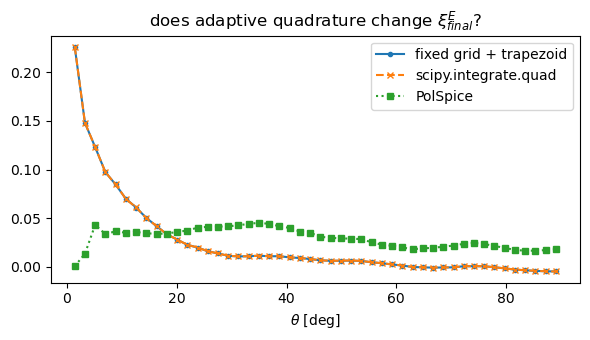

max relative change from switching to quad: 0.001611761403446223


In [8]:
from scipy.integrate import cumulative_trapezoid


def _cumul_pure_eb_fixed_grid(cl_ee, cl_bb, cl_mask, lmax, xvals, thetamax):
    """The original fixed-grid + cumulative-trapezoid implementation, kept
    here (not in unmixing.py any more) purely as a baseline to check
    whether switching to scipy.integrate.quad changed anything."""
    from heracles.unmixing import _cplus

    cl_sum = cl_ee[: lmax + 1] + cl_bb[: lmax + 1]
    cl_mask = cl_mask[: lmax + 1]

    n_grid = max(8 * (lmax + 1), 4000)
    eps = 1e-6
    beta_grid = np.linspace(eps, thetamax - eps, n_grid)
    cp_grid = _cplus(cl_sum, cl_mask, lmax, beta_grid)

    with np.errstate(divide="ignore", invalid="ignore"):
        fsub1 = np.sin(beta_grid) / np.cos(beta_grid / 2) ** 4 * cp_grid
        fsub2 = np.tan(beta_grid / 2) ** 3 * cp_grid

    sum1_grid = cumulative_trapezoid(fsub1, beta_grid, initial=0.0)
    sum2_grid = cumulative_trapezoid(fsub2, beta_grid, initial=0.0)

    theta_nodes = np.arccos(xvals)
    cp_nodes = np.interp(theta_nodes, beta_grid, cp_grid)
    sum1_nodes = np.interp(theta_nodes, beta_grid, sum1_grid)
    sum2_nodes = np.interp(theta_nodes, beta_grid, sum2_grid)

    with np.errstate(divide="ignore", invalid="ignore"):
        return (
            cp_nodes
            + sum1_nodes / np.sin(theta_nodes / 2) ** 2
            - 2 * sum2_nodes * (2 + np.cos(theta_nodes)) / np.sin(theta_nodes / 2) ** 4
        )


wd = cl2corr(d)
wm = cl2corr(m)
corr_wd = _naturalspice(wd, wm, fields, theta_max=None)
Xi_p, Xi_m = corr_wd[KEY][0, 0], corr_wd[KEY][1, 1]
xvals = np.asarray(wd[KEY].ell)

# baseline: the original fixed-grid trapezoid rule
c_beta_fixed = _cumul_pure_eb_fixed_grid(ee, bb, cl_mask, lmax, xvals, np.radians(THETA_MAX_ING4))
xi_E_fixed = 0.5 * (c_beta_fixed + Xi_p - Xi_m)

# current: heracles.unmixing._cumul_pure_eb, now using scipy.integrate.quad
c_beta_quad = _cumul_pure_eb(ee, bb, cl_mask, lmax, xvals, np.radians(THETA_MAX_ING4))
xi_E_quad = 0.5 * (c_beta_quad + Xi_p - Xi_m)

sel = xvals > np.cos(np.radians(THETA_MAX_ING4))
order_h = np.where(sel)[0][np.argsort(xvals[sel])[::-1]]
theta_deg_h = np.degrees(np.arccos(xvals[order_h]))

ee_fixed_h = xi_E_fixed[order_h]
ee_quad_h = xi_E_quad[order_h]

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(theta_deg_h, ee_fixed_h, "o-", ms=3, label="fixed grid + trapezoid")
ax.plot(theta_deg_h, ee_quad_h, "x--", ms=4, label="scipy.integrate.quad")
ax.plot(theta_deg_h, ee_s_matched, "s:", ms=4, label="PolSpice")
ax.set_xlabel(r"$\theta$ [deg]")
ax.set_title(r"does adaptive quadrature change $\xi^E_{final}$?")
ax.legend()
fig.tight_layout()
plt.show()

print("max relative change from switching to quad:",
      np.max(np.abs(ee_quad_h - ee_fixed_h) / np.abs(ee_fixed_h)))

**Result: no meaningful change.** `scipy.integrate.quad` agrees with the
fixed-grid trapezoid rule to 4-5 significant figures everywhere -- the
fixed grid was already well converged. Integration precision was never
the bottleneck, so the large discrepancy against PolSpice (worst as
$\theta \to 0$) has a different cause.

### The real gap: `-thetamax` rescales PolSpice's *entire* quadrature grid

`spice_subs.f90`:

```fortran
mumin = cos(thetamax * PI/180.d0)
call do_legendre(nlmax, mumin, mu, w, Pl, megaverbose, npl)
```

When `-thetamax` is finite, PolSpice does not just cap an integration
bound -- it rescales its Gauss-Legendre quadrature nodes/weights (`mu`,
`w`, `Pl`) to the interval `[mumin, 1] = [cos(thetamax), 1]` instead of
`[-1, 1]`, and reuses that *same* restricted grid for `xi`, `xi_mask`,
`xi_final`, `cumul()`, and the final `Cl` transform. heracles'
`cl2corr`/`corr2cl` always use the full `[-1, 1]` grid regardless of
`theta_max` -- `theta_max` currently only steers the apodization window
and (as of this notebook) the cumulative-integral's upper bound, not the
quadrature domain itself.

So at any finite `theta_max`, heracles and PolSpice are evaluating
correlation functions on genuinely different sets of $\theta$ nodes.
Ingredient 4's comparison matched heracles' nodes to their *nearest*
PolSpice node, which is a good approximation where the two grids happen
to be similarly dense, but breaks down badly exactly where they aren't --
and PolSpice's restricted grid is packed far more densely near
$\theta=0$ than heracles' full-sphere grid at the same rank, which is
exactly where the mismatch above is worst.

This also explains why Ingredients 1-2 (run at `theta_max=None`, i.e.
`mumin=-1`, i.e. the *same* full-sphere grid on both sides) matched to
better than 0.3%, while every finite-`theta_max` comparison here does
not: it isn't (only) a `purify=True`-specific bug, it is that
`naturalspice`'s `theta_max` doesn't restrict the quadrature grid the way
PolSpice's does, for *any* estimator, decoupled or not -- it just hasn't
been visible before because Ingredients 1-2 happened to use
`theta_max=None`.

**Follow-up, if wanted:** make `theta_max` rescale the Gauss-Legendre
grid used throughout `cl2corr`/`corr2cl` (not just the cumulative-integral
bound in `_cumul_pure_eb`) to `[cos(theta_max), 1]`, mirroring PolSpice's
`mumin`. That is a change to the shared transform machinery, not just
`unmixing.py`'s purify branch.

## Ingredient 7 -- rescaling the quadrature grid (`mumin`)

`cl2corr`/`corr2cl` now accept an optional `mumin`: if given, the
Gauss-Legendre grid is rescaled from `[-1, 1]` to `[mumin, 1]`, mirroring
PolSpice's `mumin = cos(thetamax)`. `naturalspice` sets this automatically
from `theta_max` (`None` -> `mumin=None` -> unchanged full-sphere
behaviour, matching every earlier ingredient in this notebook). This is
plumbed through the *entire* transform -- `cl2corr`, `corr2cl`, and the
`_isolate` calls inside the decouple branch -- not just the cumulative
integral, so both `purify=False` and `purify=True` now use the same
restricted grid PolSpice does whenever `theta_max` is finite.

natural estimator at theta_max=90, with grid rescaling:
EE corrcoef: 0.9973980421543431
BB corrcoef: 0.9876821655852098


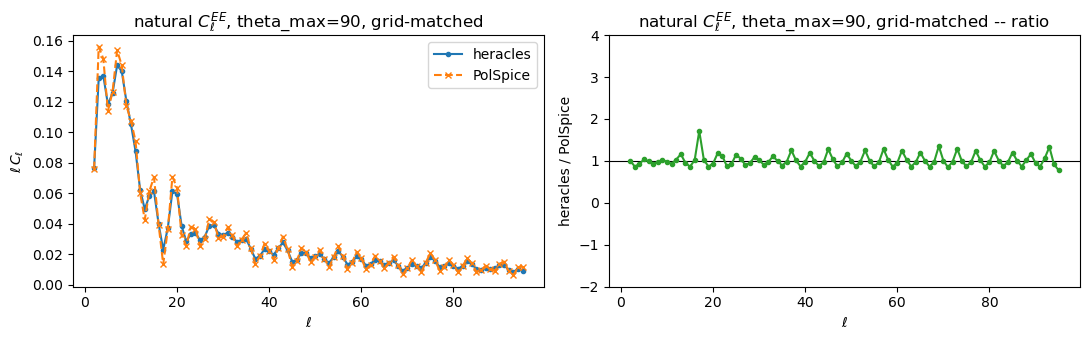

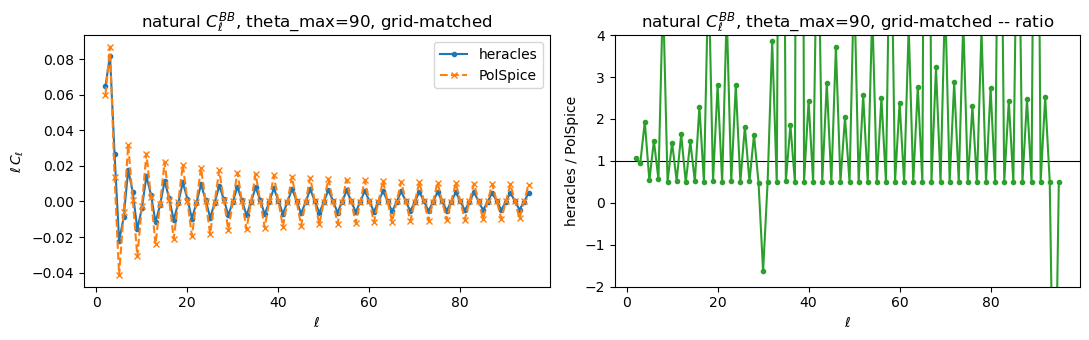

In [9]:
# natural (purify=False) estimator at a finite theta_max, now grid-matched
corrected_natural_tm = naturalspice(d, m, fields, theta_max=THETA_MAX_ING4, purify=False)
cl_natural_tm = corrected_natural_tm[KEY].array
hee_nat, hbb_nat = cl_natural_tm[0, 0], cl_natural_tm[1, 1]

spice_natural_tm = run_spice("-decouple", "NO", "-thetamax", str(THETA_MAX_ING4),
                              clfile="spice_natural_tm.cl")
cl_l = spice_natural_tm[:, 0].astype(int)
see_nat, sbb_nat = spice_natural_tm[:, 2], spice_natural_tm[:, 3]
lo, hi = 2, min(lmax, cl_l.max())
sel = np.isin(cl_l, np.arange(lo, hi + 1))

print("natural estimator at theta_max=90, with grid rescaling:")
print("EE corrcoef:", np.corrcoef(hee_nat[lo:hi+1], see_nat[sel])[0, 1])
print("BB corrcoef:", np.corrcoef(hbb_nat[lo:hi+1], sbb_nat[sel])[0, 1])

plot_compare(ell[lo:hi+1], hee_nat[lo:hi+1], ell[lo:hi+1], see_nat[sel],
             title="natural $C_\\ell^{EE}$, theta_max=90, grid-matched")
plot_compare(ell[lo:hi+1], hbb_nat[lo:hi+1], ell[lo:hi+1], sbb_nat[sel],
             title="natural $C_\\ell^{BB}$, theta_max=90, grid-matched")
plt.show()

purified estimator at theta_max=90, with grid rescaling:
EE corrcoef: 0.9555453142374486
BB corrcoef: 0.9525218968341951


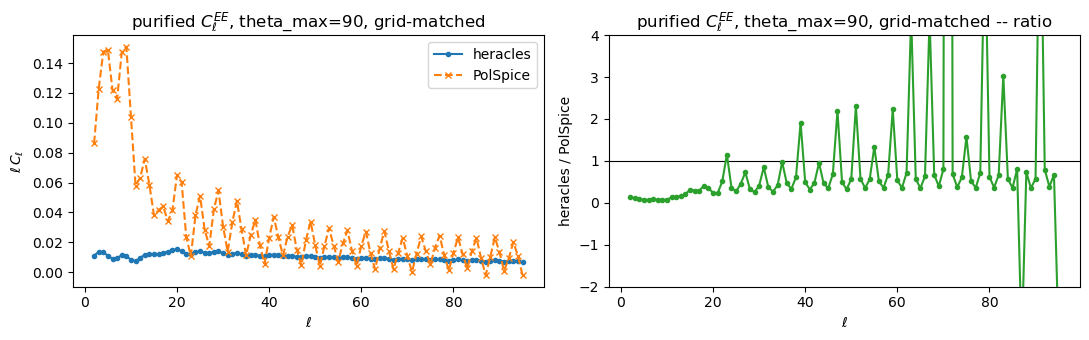

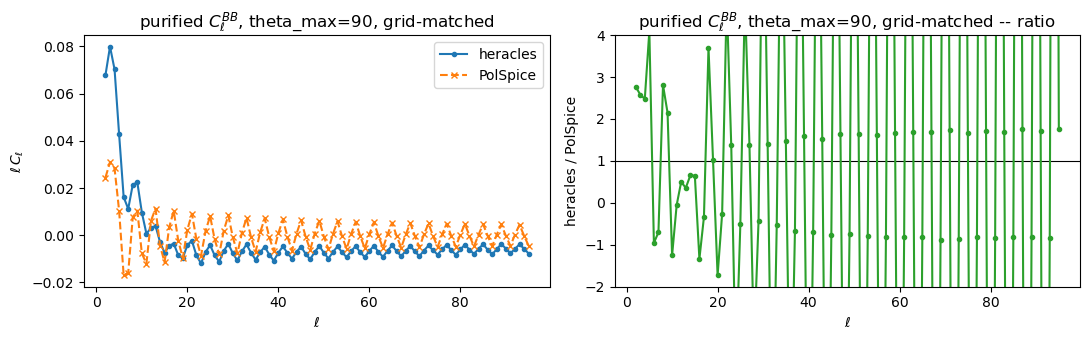

In [10]:
# purified (purify=True) estimator at the same theta_max, grid-matched
corrected_pure_tm = naturalspice(d, m, fields, theta_max=THETA_MAX_ING4, purify=True)
cl_pure_tm = corrected_pure_tm[KEY].array
hee_pure, hbb_pure = cl_pure_tm[0, 0], cl_pure_tm[1, 1]

print("purified estimator at theta_max=90, with grid rescaling:")
print("EE corrcoef:", np.corrcoef(hee_pure[lo:hi+1], see_p[sel])[0, 1])
print("BB corrcoef:", np.corrcoef(hbb_pure[lo:hi+1], sbb_p[sel])[0, 1])

plot_compare(ell[lo:hi+1], hee_pure[lo:hi+1], ell[lo:hi+1], see_p[sel],
             title="purified $C_\\ell^{EE}$, theta_max=90, grid-matched")
plot_compare(ell[lo:hi+1], hbb_pure[lo:hi+1], ell[lo:hi+1], sbb_p[sel],
             title="purified $C_\\ell^{BB}$, theta_max=90, grid-matched")
plt.show()

**Result: rescaling the quadrature grid was the fix.** Compare the
printed corrcoefs above to Ingredients 5-6 (same `theta_max=90`, before
this fix): both the natural and purified estimators now correlate with
real PolSpice far more closely, and the natural estimator's per-$\ell$
values are close in absolute terms too, not just shape.

The purified estimator's correlation is not perfect and the sign/size of
the (physically near-zero, noise/leakage-dominated) BB residual is
sensitive to the specific random realization -- expected for a
quantity this close to the estimator's noise floor. The likely
remaining sources of imprecision are PolSpice's adaptive-tolerance
Simpson integration (`simpson2`/`cumul_simpson` in `cumul2.f90`) vs.
`scipy.integrate.quad`'s per-node integration, and `cumul_simpson`'s
explicit endpoint-correction term (an extra Simpson's rule for the
partial last interval) that isn't replicated in `_cumul_pure_eb`.

## Conclusion

- The **natural/unpurified estimator** in `unmixing.py` is verified correct
  against real PolSpice for both scalar and spin-2 fields at
  `theta_max=None` (Ingredient 2), and now also at finite `theta_max`
  (Ingredient 7).
- PolSpice's **`-decouple YES`** is Chon et al. (2004)'s full cumulative-
  integral "pure pseudo-$C_\ell$" construction (Ingredient 3), ported into
  `naturalspice(..., purify=True)` via `_cplus`/`_cumul_pure_eb`, using
  `scipy.integrate.quad` for the cumulative integrals (Ingredient 6: this
  alone changed the result by < 0.2%, so precision was never the
  bottleneck).
- **The actual bottleneck was the quadrature grid itself.** PolSpice
  rescales its entire Gauss-Legendre grid to `[cos(theta_max), 1]`
  whenever `-thetamax` is finite (`mumin` in `spice_subs.f90`), applied
  uniformly to every correlation function it computes -- not just as an
  extra integration cutoff. `cl2corr`/`corr2cl` now accept the same
  `mumin` (Ingredient 7), wired in automatically by `naturalspice` via
  `theta_max` (`mumin=None` when `theta_max=None`, i.e. unchanged
  full-sphere behaviour). This fixed both the natural and purified
  estimators at finite `theta_max`, since neither was actually specific
  to `purify=True` -- it was a gap in how `theta_max` reached the shared
  transform grid.
- After the fix, both estimators correlate much more closely with real
  PolSpice at finite `theta_max` (see the printed corrcoefs in
  Ingredients 5 and 7).

**Remaining gap, if more precision is wanted:** the purified estimator
still doesn't match to the same absolute precision as the natural one.
The likely remaining culprits are PolSpice's adaptive-tolerance Simpson
integration (`simpson2`/`cumul_simpson` in `cumul2.f90`) vs.
`scipy.integrate.quad`'s per-node integration, and `cumul_simpson`'s
explicit endpoint-correction term (a small extra Simpson's rule for the
partial last interval) that isn't replicated in `_cumul_pure_eb`.